In [1]:
import pytz
from datetime import datetime
from dateutil.relativedelta import relativedelta
from skyfield.api import load, wgs84, EarthSatellite
import numpy as np

## Standard satellite TLE query

In [2]:
# # Download satellite TLE data from NORAD
# stations_url = 'https://www.celestrak.com/NORAD/elements/stations.txt'
# satellites = load.tle_file(stations_url)
# by_name = {sat.name: sat for sat in satellites}

In [3]:
# ts = load.timescale()
# # satellite = EarthSatellite(line1, line2, 'HST', ts)
# satellite=by_name['ISS (NAUKA)']
# print(satellite)

# # Get the current time in a timezone-aware fashion.

# tz = pytz.timezone('UTC')
# dt = tz.localize(datetime.utcnow())
# print(f"Exectution time: {dt:%Y-%m-%d %H:%M:%S %Z}\n")

# # Split the next 200 minutes into a collection of 101-evenly
# # spaced Timescales (every two minutes, plus endpoints)

# t0 = ts.utc(dt)
# t1 = ts.utc(dt + relativedelta(minutes=100))
# timescales = ts.linspace(t0, t1, 1000)

# # calculate the subpoints.

# geocentrics = satellite.at(timescales)
# points= wgs84.subpoint_of(geocentrics)

In [4]:
# longitude=(points.longitude.degrees)
# latitude=(points.latitude.degrees)
# print(f'Altitude is {wgs84.height_of(satellite.at(t0)).km}')

In [5]:
# from src2.shapecheck import shapecheck
# shapecheck(longitude,latitude,'')

## Customize satellite with self defined orbital elements

In [50]:
ts = load.timescale()
line1='1 25994U 99068A   99352.83522818 -.00000049  00000-0  00000+0 0    13'
line2='2 25994  98.2112  66.9361 0026528 147.8117 212.9753 14.64664121    01'

satellite = EarthSatellite(line1, line2, 'Landsat-8', ts)
print(satellite)

# Get the current time in a timezone-aware fashion.

tz = pytz.timezone('UTC')
dt = tz.localize(datetime.utcnow())
print(f"Exectution time: {dt:%Y-%m-%d %H:%M:%S %Z}\n")

# Split the next 200 minutes into a collection of 101-evenly
# spaced Timescales (every two minutes, plus endpoints)

t0 = ts.utc(dt)
t1 = ts.utc(dt + relativedelta(minutes=100))
timescales = ts.linspace(t0, t1, 100)

# calculate the subpoints.

geocentrics = satellite.at(timescales)

subpoints = wgs84.subpoint_of(geocentrics)
altitude=wgs84.height_of(satellite.at(t0)).km
print(altitude)

Landsat-8 catalog #25994 epoch 1999-12-18 20:02:44 UTC
Exectution time: 2024-03-27 10:56:35 UTC

677.132952131641


In [51]:
timescales

<Time tt=[2460396.956769475 ... 2460397.0262139193] len=100>

In [52]:
dt.year

2024

In [53]:
type(satellite.epoch.ut1)

numpy.float64

In [54]:
finvel=np.sqrt((geocentrics.velocity.km_per_s[0])**2+(geocentrics.velocity.km_per_s[1])**2+(geocentrics.velocity.km_per_s[2])**2)

In [55]:
# 2024-02-26 03:17:08

In [56]:
Lon,Lat=subpoints.longitude.degrees,subpoints.latitude.degrees

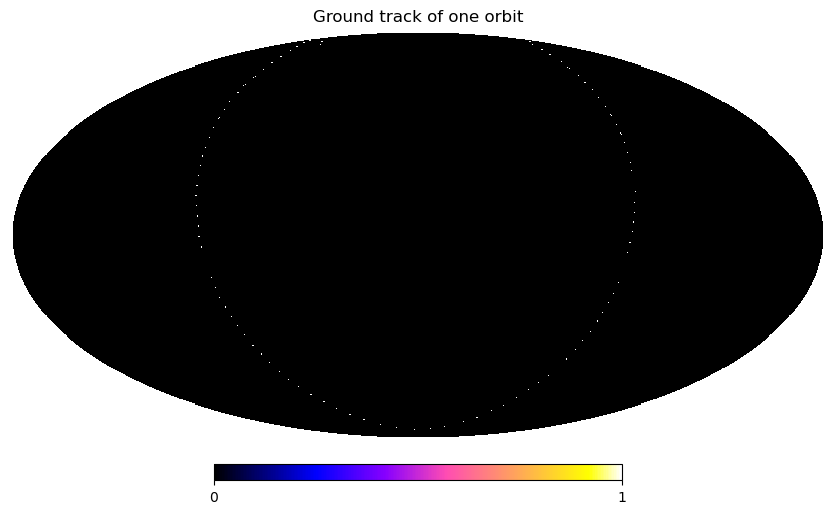

In [57]:
from src2.shapecheck import shapecheck
shapecheck(Lon,Lat,'Ground track of one orbit')
# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper_images/GT.pdf',dpi=600,bbox_inches='tight')


In [58]:
# import pandas as pd
# df=pd.DataFrame({'Lon':Lon,'Lat':Lat})
# df.to_csv('/home/pratush/Desktop/neworbit.csv')

In [14]:
Lon[0],Lat[0]

(168.70577855871505, 63.164920397169375)

In [11]:
sunlit=geocentrics.is_sunlit(eph)
timescales.utc[5,2]-timescales.utc[5,1]

NameError: name 'eph' is not defined

In [48]:
import healpy as hp


1.8322594196359498

In [49]:
111.320*hp.nside2resol(32,arcmin=True)/60

203.96711859387395